In [1]:
# ==========================================
# Mutual Fund Analytics - Performance Analysis
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import linregress

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ==========================================
# Load Required Datasets
# ==========================================

# Project root
BASE_DIR = Path.cwd().parent

# Processed data folder
DATA_DIR = BASE_DIR / "data" / "processed"

# Load datasets
fund_master = pd.read_csv(DATA_DIR / "01_fund_master.csv")

nav_history = pd.read_csv(
    DATA_DIR / "02_nav_history_cleaned.csv"
)

scheme_performance = pd.read_csv(
    DATA_DIR / "07_scheme_performance_cleaned.csv"
)

benchmark_indices = pd.read_csv(
    DATA_DIR / "10_benchmark_indices.csv"
)

print("Required datasets loaded successfully.")

print("\nFund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("Scheme Performance:", scheme_performance.shape)
print("Benchmark Indices:", benchmark_indices.shape)

Required datasets loaded successfully.

Fund Master: (40, 15)
NAV History: (46000, 3)
Scheme Performance: (40, 20)
Benchmark Indices: (8050, 3)


In [4]:
# ==========================================
# Inspect Dataset Structure
# ==========================================

print("NAV History Columns:")
print(nav_history.columns.tolist())

print("\nScheme Performance Columns:")
print(scheme_performance.columns.tolist())

print("\nBenchmark Indices Columns:")
print(benchmark_indices.columns.tolist())

print("\nNAV History Sample:")
display(nav_history.head())

print("\nBenchmark Indices Sample:")
display(benchmark_indices.head())

NAV History Columns:
['amfi_code', 'date', 'nav']

Scheme Performance Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'expense_ratio_anomaly']

Benchmark Indices Columns:
['date', 'index_name', 'close_value']

NAV History Sample:


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639



Benchmark Indices Sample:


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [5]:
# ==========================================
# Step 6: Compute Daily Returns
# ==========================================

# Convert date column to datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Sort correctly before calculating returns
nav_history = nav_history.sort_values(
    by=["amfi_code", "date"]
).reset_index(drop=True)

# Daily return = NAV_t / NAV_t-1 - 1
nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

print("Daily returns calculated successfully.")

print("\nTotal schemes:")
print(nav_history["amfi_code"].nunique())

print("\nDaily Return Summary:")
display(nav_history["daily_return"].describe())

print("\nSample:")
display(
    nav_history[
        ["date", "amfi_code", "nav", "daily_return"]
    ].head(10)
)

Daily returns calculated successfully.

Total schemes:
40

Daily Return Summary:


count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


Sample:


,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210
5,2022-01-10,100016,510.7136,-0.008639
6,2022-01-11,100016,513.5542,0.005562
7,2022-01-12,100016,512.3195,-0.002404
8,2022-01-13,100016,510.2445,-0.004050
9,2022-01-14,100016,514.3636,0.008073


Daily Return Validation
----------------------------------------
Mean Daily Return: 0.000631
Median Daily Return: 0.000340
Standard Deviation: 0.010290
Minimum Daily Return: -0.058102
Maximum Daily Return: 0.064713


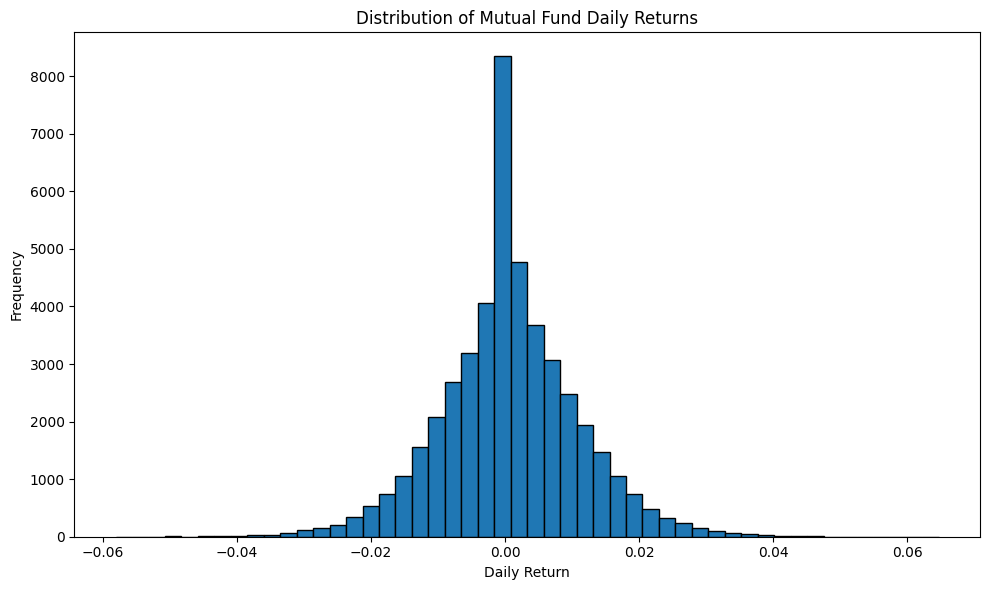

In [6]:
# ==========================================
# Step 7: Validate Daily Return Distribution
# ==========================================

valid_returns = nav_history["daily_return"].dropna()

print("Daily Return Validation")
print("-" * 40)

print(f"Mean Daily Return: {valid_returns.mean():.6f}")
print(f"Median Daily Return: {valid_returns.median():.6f}")
print(f"Standard Deviation: {valid_returns.std():.6f}")
print(f"Minimum Daily Return: {valid_returns.min():.6f}")
print(f"Maximum Daily Return: {valid_returns.max():.6f}")

# Distribution chart
plt.figure(figsize=(10, 6))

plt.hist(
    valid_returns,
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Mutual Fund Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [7]:
# ==========================================
# Step 8: Calculate CAGR
# ==========================================

def calculate_cagr(group, years):
    group = group.sort_values("date").dropna(subset=["nav"])

    if len(group) < 2:
        return np.nan

    end_date = group["date"].max()
    target_date = end_date - pd.DateOffset(years=years)

    # Data available up to the target date
    old_data = group[group["date"] <= target_date]

    if old_data.empty:
        return np.nan

    start_row = old_data.iloc[-1]
    end_row = group.iloc[-1]

    start_nav = start_row["nav"]
    end_nav = end_row["nav"]

    actual_years = (
        (end_row["date"] - start_row["date"]).days / 365.25
    )

    if start_nav <= 0 or actual_years <= 0:
        return np.nan

    return ((end_nav / start_nav) ** (1 / actual_years) - 1) * 100


cagr_results = []

for amfi_code, fund_data in nav_history.groupby("amfi_code"):

    cagr_results.append({
        "amfi_code": amfi_code,
        "cagr_1yr_pct": calculate_cagr(fund_data, 1),
        "cagr_3yr_pct": calculate_cagr(fund_data, 3),
        "cagr_5yr_pct": calculate_cagr(fund_data, 5)
    })

cagr_df = pd.DataFrame(cagr_results)

# Add scheme details
cagr_df = cagr_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house", "category"]
    ],
    on="amfi_code",
    how="left"
)

print("CAGR calculated successfully.")
print("Funds analysed:", len(cagr_df))

display(cagr_df.head(10))

CAGR calculated successfully.
Funds analysed: 40


,amfi_code,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct,scheme_name,fund_house,category
0,100016,-2.225777,1.292353,NaN,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
1,100025,3.707553,3.915479,NaN,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt
2,100033,53.277195,32.433971,NaN,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity
3,101206,47.963794,28.960211,NaN,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
4,101207,-24.000309,-4.151454,NaN,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
5,101208,7.241777,6.314299,NaN,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Debt
6,102885,20.222859,19.662361,NaN,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Equity
7,102886,-16.807960,-0.767232,NaN,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity
8,102887,13.593044,25.549670,NaN,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Equity
9,118632,34.007896,22.646647,NaN,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity


In [8]:
# ==========================================
# Step 9: Calculate Sharpe Ratio
# Risk-Free Rate = 6.5% annually
# ==========================================

RISK_FREE_RATE = 0.065
TRADING_DAYS = 252

# Convert annual risk-free rate to daily rate
daily_risk_free = (1 + RISK_FREE_RATE) ** (1 / TRADING_DAYS) - 1

sharpe_results = []

for amfi_code, fund_data in nav_history.groupby("amfi_code"):

    returns = fund_data["daily_return"].dropna()

    if len(returns) > 1 and returns.std() != 0:

        excess_returns = returns - daily_risk_free

        sharpe_ratio = (
            excess_returns.mean() / returns.std()
        ) * np.sqrt(TRADING_DAYS)

    else:
        sharpe_ratio = np.nan

    sharpe_results.append({
        "amfi_code": amfi_code,
        "sharpe_ratio": sharpe_ratio
    })

sharpe_df = pd.DataFrame(sharpe_results)

# Add scheme information
sharpe_df = sharpe_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house", "category"]
    ],
    on="amfi_code",
    how="left"
)

print("Sharpe Ratio calculated successfully.")
print("Funds analysed:", len(sharpe_df))

display(
    sharpe_df.sort_values(
        "sharpe_ratio",
        ascending=False
    ).head(10)
)

Sharpe Ratio calculated successfully.
Funds analysed: 40


,amfi_code,sharpe_ratio,scheme_name,fund_house,category
34,148567,1.462504,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity
30,120843,1.319442,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity
36,148569,1.246344,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity
19,119551,1.222947,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
25,120505,1.190559,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity
38,149323,1.143490,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity
2,100033,1.104352,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity
9,118632,1.095918,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity
3,101206,1.041061,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
24,120504,1.040569,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity


In [9]:
# ==========================================
# Step 10: Calculate Sortino Ratio
# Risk-Free Rate = 6.5% annually
# ==========================================

sortino_results = []

for amfi_code, fund_data in nav_history.groupby("amfi_code"):

    returns = fund_data["daily_return"].dropna()

    if len(returns) > 1:

        excess_returns = returns - daily_risk_free

        # Only negative excess returns = downside risk
        downside_returns = excess_returns[excess_returns < 0]

        if len(downside_returns) > 1:
            downside_deviation = np.sqrt(
                np.mean(downside_returns ** 2)
            )

            if downside_deviation != 0:
                sortino_ratio = (
                    excess_returns.mean()
                    / downside_deviation
                ) * np.sqrt(TRADING_DAYS)
            else:
                sortino_ratio = np.nan
        else:
            sortino_ratio = np.nan

    else:
        sortino_ratio = np.nan

    sortino_results.append({
        "amfi_code": amfi_code,
        "sortino_ratio": sortino_ratio
    })


sortino_df = pd.DataFrame(sortino_results)

sortino_df = sortino_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house", "category"]
    ],
    on="amfi_code",
    how="left"
)

print("Sortino Ratio calculated successfully.")
print("Funds analysed:", len(sortino_df))

display(
    sortino_df.sort_values(
        "sortino_ratio",
        ascending=False
    ).head(10)
)

Sortino Ratio calculated successfully.
Funds analysed: 40


,amfi_code,sortino_ratio,scheme_name,fund_house,category
34,148567,1.477680,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity
30,120843,1.396262,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity
36,148569,1.314891,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity
19,119551,1.277845,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
25,120505,1.250035,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity
38,149323,1.147405,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity
2,100033,1.133525,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity
9,118632,1.120520,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity
3,101206,1.084557,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
16,119094,1.060754,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity


In [10]:
print("Available Benchmark Indices:")
print(benchmark_indices["index_name"].unique())

Available Benchmark Indices:
['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [11]:
# ==========================================
# Step 12: Prepare NIFTY 100 Daily Returns
# ==========================================

benchmark_indices["date"] = pd.to_datetime(
    benchmark_indices["date"]
)

benchmark_indices = benchmark_indices.sort_values(
    ["index_name", "date"]
)

# Find NIFTY 100 automatically
nifty100_name = next(
    name for name in benchmark_indices["index_name"].unique()
    if "100" in str(name).replace(" ", "").upper()
)

nifty100 = benchmark_indices[
    benchmark_indices["index_name"] == nifty100_name
].copy()

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

print("NIFTY 100 benchmark selected:", nifty100_name)
print("Benchmark rows:", len(nifty100))

display(nifty100.head())

NIFTY 100 benchmark selected: NIFTY100
Benchmark rows: 1150


,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [12]:
# ==========================================
# Step 13: Alpha & Beta vs NIFTY 100
# ==========================================

alpha_beta_results = []

for amfi_code, fund_data in nav_history.groupby("amfi_code"):

    fund_returns = fund_data[
        ["date", "daily_return"]
    ].dropna()

    merged = fund_returns.merge(
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 30:

        regression = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = regression.slope

        # Annualised alpha in percentage terms
        alpha_pct = regression.intercept * 252 * 100

    else:
        beta = np.nan
        alpha_pct = np.nan

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha_pct": alpha_pct,
        "beta": beta,
        "observations": len(merged)
    })


alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df = alpha_beta_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house", "category"]
    ],
    on="amfi_code",
    how="left"
)

print("Alpha & Beta calculated successfully.")
print("Funds analysed:", len(alpha_beta_df))

display(
    alpha_beta_df.sort_values(
        "alpha_pct",
        ascending=False
    ).head(10)
)

Alpha & Beta calculated successfully.
Funds analysed: 40


,amfi_code,alpha_pct,beta,observations,scheme_name,fund_house,category
21,119598,30.336965,-0.023196,1149,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
39,149324,30.057878,0.011455,1149,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity
25,120505,29.263583,0.000549,1149,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity
36,148569,28.270368,0.018134,1149,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity
30,120843,27.330465,-0.022830,1149,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity
2,100033,27.195355,0.005104,1149,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity
34,148567,26.983751,0.023684,1149,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity
38,149323,26.598578,-0.002523,1149,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity
16,119094,26.076669,-0.066265,1149,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity
19,119551,23.201007,-0.031751,1149,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity


In [13]:
# ==========================================
# Export Alpha-Beta Results
# ==========================================

REPORT_DIR = BASE_DIR / "reports"
REPORT_DIR.mkdir(exist_ok=True)

alpha_beta_path = REPORT_DIR / "alpha_beta.csv"

alpha_beta_df.to_csv(
    alpha_beta_path,
    index=False
)

print("Saved:", alpha_beta_path)

Saved: c:\Users\saisr\OneDrive\Desktop\BlueStock Internship\Mutual_Fund_Analytics\reports\alpha_beta.csv


In [14]:
# ==========================================
# Step 15: Maximum Drawdown
# ==========================================

drawdown_results = []

for amfi_code, fund_data in nav_history.groupby("amfi_code"):

    fund_data = (
        fund_data
        .sort_values("date")
        .dropna(subset=["nav"])
        .copy()
    )

    fund_data["running_peak"] = (
        fund_data["nav"].cummax()
    )

    fund_data["drawdown"] = (
        fund_data["nav"]
        / fund_data["running_peak"]
        - 1
    )

    max_drawdown = fund_data["drawdown"].min()

    trough_index = fund_data["drawdown"].idxmin()
    trough_date = fund_data.loc[
        trough_index, "date"
    ]

    peak_data = fund_data[
        fund_data["date"] <= trough_date
    ]

    peak_index = peak_data["nav"].idxmax()
    peak_date = fund_data.loc[
        peak_index, "date"
    ]

    drawdown_results.append({
        "amfi_code": amfi_code,
        "max_drawdown_pct": max_drawdown * 100,
        "drawdown_start": peak_date,
        "drawdown_bottom": trough_date
    })


drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df = drawdown_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house", "category"]
    ],
    on="amfi_code",
    how="left"
)

print("Maximum Drawdown calculated successfully.")
print("Funds analysed:", len(drawdown_df))

display(
    drawdown_df.sort_values(
        "max_drawdown_pct"
    ).head(10)
)

Maximum Drawdown calculated successfully.
Funds analysed: 40


,amfi_code,max_drawdown_pct,drawdown_start,drawdown_bottom,scheme_name,fund_house,category
22,119599,-52.574221,2023-01-17,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity
17,119095,-51.677754,2025-05-22,2026-05-11,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity
4,101207,-35.446916,2024-11-21,2026-05-11,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
39,149324,-31.171900,2024-05-03,2025-01-03,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity
21,119598,-28.706006,2024-08-28,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
7,102886,-28.001124,2025-01-07,2026-04-27,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity
0,100016,-24.734441,2022-03-30,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
29,120842,-24.003511,2023-11-09,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Equity
11,118634,-23.344886,2025-04-09,2026-02-20,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity
15,119093,-21.751396,2022-02-24,2023-05-22,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,Equity


In [15]:
# ==========================================
# Step 16: Combine Performance Metrics
# ==========================================

performance_metrics = (
    cagr_df[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "cagr_1yr_pct",
            "cagr_3yr_pct",
            "cagr_5yr_pct"
        ]
    ]
    .merge(
        sharpe_df[
            ["amfi_code", "sharpe_ratio"]
        ],
        on="amfi_code",
        how="left"
    )
    .merge(
        sortino_df[
            ["amfi_code", "sortino_ratio"]
        ],
        on="amfi_code",
        how="left"
    )
    .merge(
        alpha_beta_df[
            ["amfi_code", "alpha_pct", "beta"]
        ],
        on="amfi_code",
        how="left"
    )
    .merge(
        drawdown_df[
            ["amfi_code", "max_drawdown_pct"]
        ],
        on="amfi_code",
        how="left"
    )
)

# Add expense ratio
performance_metrics = performance_metrics.merge(
    fund_master[
        ["amfi_code", "expense_ratio_pct"]
    ],
    on="amfi_code",
    how="left"
)

print("Performance metrics combined successfully.")
print("Funds:", len(performance_metrics))

display(performance_metrics.head())

Performance metrics combined successfully.
Funds: 40


,amfi_code,scheme_name,fund_house,category,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct,sharpe_ratio,sortino_ratio,alpha_pct,beta,max_drawdown_pct,expense_ratio_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-2.225777,1.292353,NaN,-0.187650,-0.191590,3.747581,-0.058268,-24.734441,1.55
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,3.707553,3.915479,NaN,-0.515438,-0.515918,4.281792,0.001158,-4.308264,0.56
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,53.277195,32.433971,NaN,1.104352,1.133525,27.195355,0.005104,-16.217209,1.38
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,47.963794,28.960211,NaN,1.041061,1.084557,21.399785,0.021086,-11.291596,1.60
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-24.000309,-4.151454,NaN,0.170481,0.173543,10.897092,-0.065289,-35.446916,1.53


In [16]:
# ==========================================
# Step 17: Fund Scorecard (0-100)
# ==========================================

scorecard = performance_metrics.copy()


def percentile_score(series):
    return series.rank(
        pct=True,
        method="average"
    )


# Higher = better
scorecard["return_score"] = (
    percentile_score(scorecard["cagr_5yr_pct"]) * 30
)

scorecard["sharpe_score"] = (
    percentile_score(scorecard["sharpe_ratio"]) * 20
)

scorecard["sortino_score"] = (
    percentile_score(scorecard["sortino_ratio"]) * 15
)

scorecard["alpha_score"] = (
    percentile_score(scorecard["alpha_pct"]) * 15
)

# Less-negative drawdown is better
scorecard["drawdown_score"] = (
    percentile_score(scorecard["max_drawdown_pct"]) * 10
)

# Lower expense ratio is better
scorecard["expense_score"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        pct=True,
        ascending=False
    ) * 10
)


score_columns = [
    "return_score",
    "sharpe_score",
    "sortino_score",
    "alpha_score",
    "drawdown_score",
    "expense_score"
]

scorecard[score_columns] = (
    scorecard[score_columns]
    .fillna(0)
)


scorecard["fund_score"] = (
    scorecard[score_columns]
    .sum(axis=1)
    .round(2)
)


scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
).reset_index(drop=True)

scorecard["rank"] = (
    np.arange(1, len(scorecard) + 1)
)


print("Fund Scorecard created successfully.")
print("Funds ranked:", len(scorecard))

display(
    scorecard[
        [
            "rank",
            "scheme_name",
            "fund_house",
            "fund_score",
            "cagr_5yr_pct",
            "sharpe_ratio",
            "sortino_ratio",
            "alpha_pct",
            "max_drawdown_pct",
            "expense_ratio_pct"
        ]
    ].head(10)
)

Fund Scorecard created successfully.
Funds ranked: 40


,rank,scheme_name,fund_house,fund_score,cagr_5yr_pct,sharpe_ratio,sortino_ratio,alpha_pct,max_drawdown_pct,expense_ratio_pct
0,1,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,60.50,NaN,1.462504,1.477680,26.983751,-11.265729,1.46
1,2,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,59.38,NaN,1.319442,1.396262,27.330465,-12.973968,1.45
2,3,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,56.25,NaN,1.190559,1.250035,29.263583,-18.188514,1.36
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,54.12,NaN,1.104352,1.133525,27.195355,-16.217209,1.38
4,5,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,53.25,NaN,1.246344,1.314891,28.270368,-16.396743,1.60
5,6,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,52.62,NaN,1.222947,1.277845,23.201007,-15.012385,1.54
6,7,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,51.75,NaN,1.040569,1.060377,21.194827,-12.588276,0.80
7,8,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,51.12,NaN,0.967752,0.993295,19.868599,-11.803494,0.66
8,9,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,48.75,NaN,1.095918,1.120520,21.829398,-17.414075,1.51
9,10,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,48.50,NaN,1.143490,1.147405,26.598578,-17.248106,1.61


In [17]:
fund_scorecard_path = (
    REPORT_DIR / "fund_scorecard.csv"
)

scorecard.to_csv(
    fund_scorecard_path,
    index=False
)

print("Saved:", fund_scorecard_path)

Saved: c:\Users\saisr\OneDrive\Desktop\BlueStock Internship\Mutual_Fund_Analytics\reports\fund_scorecard.csv


In [18]:
top5_funds = scorecard.head(5)[
    [
        "amfi_code",
        "scheme_name",
        "fund_score"
    ]
]

print("Top 5 Ranked Funds:")

display(top5_funds)

Top 5 Ranked Funds:


,amfi_code,scheme_name,fund_score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,60.50
1,120843,Kotak Flexicap Fund - Regular - Growth,59.38
2,120505,ICICI Pru Midcap Fund - Regular - Growth,56.25
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,54.12
4,148569,Mirae Asset Tax Saver Fund - Regular - Growth,53.25


In [19]:
# ==========================================
# Step 20: Select NIFTY 50 and NIFTY 100
# ==========================================

benchmark_names = benchmark_indices[
    "index_name"
].unique()

nifty50_name = next(
    name for name in benchmark_names
    if "50" in str(name).replace(" ", "").upper()
)

nifty100_name = next(
    name for name in benchmark_names
    if "100" in str(name).replace(" ", "").upper()
)

print("NIFTY 50:", nifty50_name)
print("NIFTY 100:", nifty100_name)

NIFTY 50: NIFTY50
NIFTY 100: NIFTY100


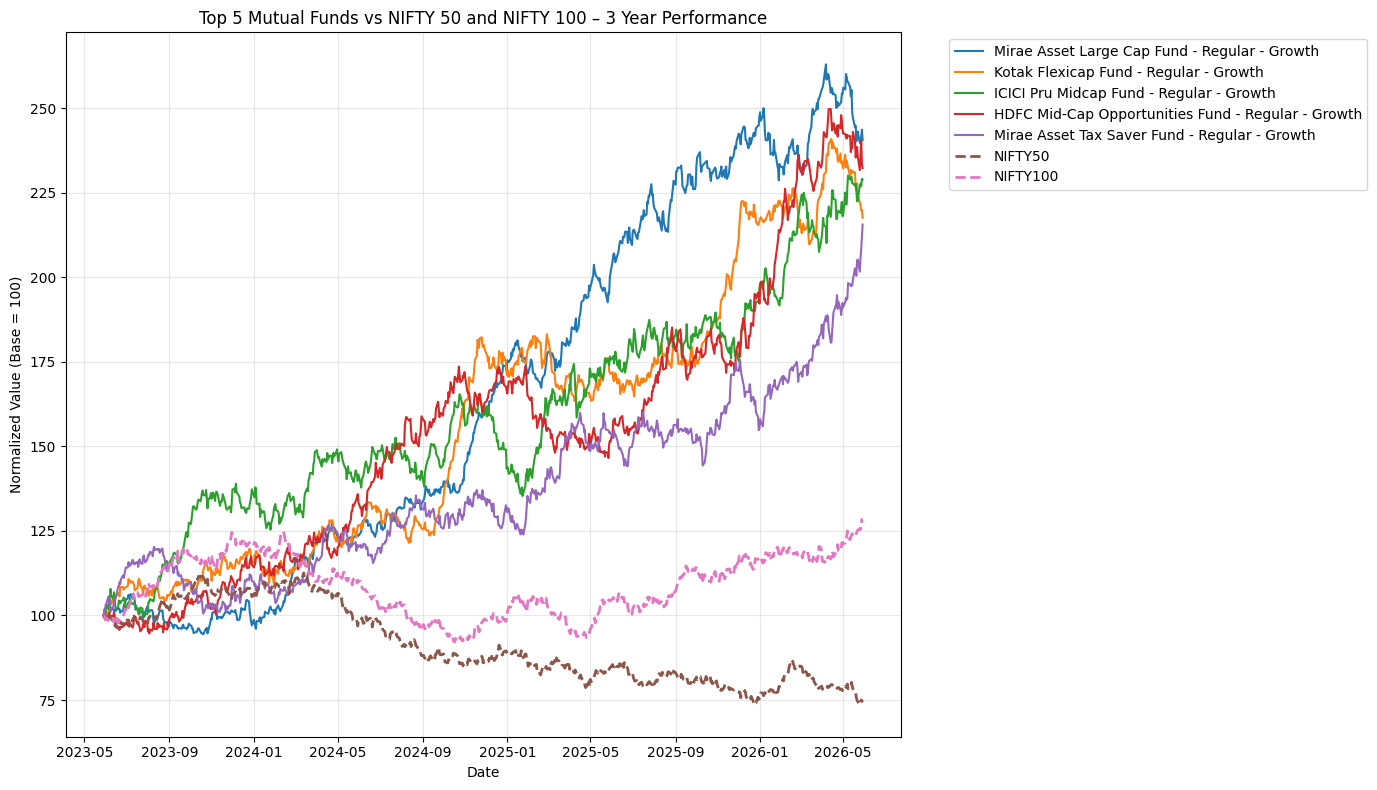

Benchmark chart saved: c:\Users\saisr\OneDrive\Desktop\BlueStock Internship\Mutual_Fund_Analytics\reports\benchmark_comparison.png


In [20]:
# ==========================================
# Step 21: Top 5 vs Benchmarks — 3 Years
# ==========================================

end_date = nav_history["date"].max()

start_date = (
    end_date - pd.DateOffset(years=3)
)

plt.figure(figsize=(14, 8))


# Plot top 5 funds
for _, row in top5_funds.iterrows():

    fund = nav_history[
        (nav_history["amfi_code"] == row["amfi_code"])
        & (nav_history["date"] >= start_date)
    ].copy()

    fund = fund.sort_values("date")

    if not fund.empty:

        fund["normalized"] = (
            fund["nav"]
            / fund["nav"].iloc[0]
            * 100
        )

        plt.plot(
            fund["date"],
            fund["normalized"],
            label=row["scheme_name"]
        )


# Plot benchmark indices
for benchmark_name in [
    nifty50_name,
    nifty100_name
]:

    bench = benchmark_indices[
        (benchmark_indices["index_name"] == benchmark_name)
        & (benchmark_indices["date"] >= start_date)
    ].copy()

    bench = bench.sort_values("date")

    if not bench.empty:

        bench["normalized"] = (
            bench["close_value"]
            / bench["close_value"].iloc[0]
            * 100
        )

        plt.plot(
            bench["date"],
            bench["normalized"],
            linestyle="--",
            linewidth=2,
            label=benchmark_name
        )


plt.title(
    "Top 5 Mutual Funds vs NIFTY 50 and NIFTY 100 – 3 Year Performance"
)

plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

benchmark_chart_path = (
    REPORT_DIR / "benchmark_comparison.png"
)

plt.savefig(
    benchmark_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Benchmark chart saved:",
    benchmark_chart_path
)

In [21]:
# ==========================================
# Step 22: Tracking Error
# ==========================================

tracking_error_results = []


for _, fund_row in top5_funds.iterrows():

    fund_returns = nav_history[
        nav_history["amfi_code"]
        == fund_row["amfi_code"]
    ][
        ["date", "daily_return"]
    ].dropna()


    for benchmark_name in [
        nifty50_name,
        nifty100_name
    ]:

        benchmark = benchmark_indices[
            benchmark_indices["index_name"]
            == benchmark_name
        ].copy()

        benchmark = benchmark.sort_values(
            "date"
        )

        benchmark["benchmark_return"] = (
            benchmark["close_value"]
            .pct_change()
        )

        merged = fund_returns.merge(
            benchmark[
                ["date", "benchmark_return"]
            ],
            on="date",
            how="inner"
        ).dropna()


        if len(merged) > 1:

            active_return = (
                merged["daily_return"]
                - merged["benchmark_return"]
            )

            tracking_error = (
                active_return.std()
                * np.sqrt(252)
                * 100
            )

        else:
            tracking_error = np.nan


        tracking_error_results.append({
            "amfi_code": fund_row["amfi_code"],
            "scheme_name": fund_row["scheme_name"],
            "benchmark": benchmark_name,
            "tracking_error_pct": tracking_error
        })


tracking_error_df = pd.DataFrame(
    tracking_error_results
)

print("Tracking Error calculated successfully.")

display(tracking_error_df)

Tracking Error calculated successfully.


,amfi_code,scheme_name,benchmark,tracking_error_pct
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY50,19.399579
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,18.966368
2,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY50,20.514777
3,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY100,20.642497
4,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY50,23.312358
5,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY100,23.196751
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY50,22.975511
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY100,22.869942
8,148569,Mirae Asset Tax Saver Fund - Regular - Growth,NIFTY50,21.938893
9,148569,Mirae Asset Tax Saver Fund - Regular - Growth,NIFTY100,21.736519


In [22]:
print("=" * 70)
print("FUND PERFORMANCE ANALYTICS SUMMARY")
print("=" * 70)

print("\nSchemes analysed:")
print(nav_history["amfi_code"].nunique())

print("\nTop 5 Funds:")
display(
    scorecard[
        [
            "rank",
            "scheme_name",
            "fund_score"
        ]
    ].head(5)
)

print("\nScore Range:")
print(
    "Highest Score:",
    scorecard["fund_score"].max()
)

print(
    "Lowest Score:",
    scorecard["fund_score"].min()
)

print("\nDeliverables generated:")
print("1. Performance_Analytics.ipynb")
print("2. fund_scorecard.csv")
print("3. alpha_beta.csv")
print("4. benchmark_comparison.png")

FUND PERFORMANCE ANALYTICS SUMMARY

Schemes analysed:
40

Top 5 Funds:


,rank,scheme_name,fund_score
0,1,Mirae Asset Large Cap Fund - Regular - Growth,60.50
1,2,Kotak Flexicap Fund - Regular - Growth,59.38
2,3,ICICI Pru Midcap Fund - Regular - Growth,56.25
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,54.12
4,5,Mirae Asset Tax Saver Fund - Regular - Growth,53.25



Score Range:
Highest Score: 60.5
Lowest Score: 8.75

Deliverables generated:
1. Performance_Analytics.ipynb
2. fund_scorecard.csv
3. alpha_beta.csv
4. benchmark_comparison.png
